In [8]:
#pip install pandas

In [9]:
import pandas as pd

In [10]:
#pip install imbalanced-learn

**import libraries**

In [11]:
#pip install scikit-learn

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,MinMaxScaler
from sklearn.model_selection import train_test_split

from imblearn.over_sampling import SMOTE

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier


from sklearn.metrics import classification_report,ConfusionMatrixDisplay,accuracy_score
import pickle

import warnings
warnings.filterwarnings('ignore')


**Read Data**

In [13]:
df=pd.read_csv(r"D:\shaham_diabetiesml\diabetes_prediction_dataset (2).csv")
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140.0,0
1,Female,54.0,0,0,No Info,27.32,6.6,80.0,0
2,Male,28.0,0,0,never,27.32,5.7,158.0,0
3,Female,36.0,0,0,current,23.45,5.0,155.0,0
4,Male,76.0,1,1,current,20.14,NaN,155.0,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90.0,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100.0,0
99997,Male,66.0,0,0,former,27.83,5.7,155.0,0
99998,Female,24.0,0,0,never,35.42,4.0,100.0,0


In [14]:
df['hypertension'].value_counts()

hypertension
0    92515
1     7485
Name: count, dtype: int64

**check basic information**

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  str    
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      99999 non-null   str    
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          99997 non-null   float64
 7   blood_glucose_level  99999 non-null   float64
 8   diabetes             100000 non-null  int64  
dtypes: float64(4), int64(3), str(2)
memory usage: 8.0 MB


check shape

In [16]:
df.shape

(100000, 9)

In [17]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140.0,0
1,Female,54.0,0,0,No Info,27.32,6.6,80.0,0
2,Male,28.0,0,0,never,27.32,5.7,158.0,0
3,Female,36.0,0,0,current,23.45,5.0,155.0,0
4,Male,76.0,1,1,current,20.14,NaN,155.0,0


In [18]:
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90.0,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100.0,0
99997,Male,66.0,0,0,former,27.83,5.7,155.0,0
99998,Female,24.0,0,0,never,35.42,4.0,100.0,0
99999,Female,57.0,0,0,current,22.43,6.6,90.0,0


**Check Missing Values**

In [19]:
df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        1
bmi                    0
HbA1c_level            3
blood_glucose_level    1
diabetes               0
dtype: int64

**Check Datatype**

In [20]:
df["HbA1c_level"] = df["HbA1c_level"].fillna(df["HbA1c_level"].mean())

In [21]:
df["blood_glucose_level"] = df["blood_glucose_level"].fillna(df["blood_glucose_level"].mean())

In [22]:
df.dtypes

gender                     str
age                    float64
hypertension             int64
heart_disease            int64
smoking_history            str
bmi                    float64
HbA1c_level            float64
blood_glucose_level    float64
diabetes                 int64
dtype: object

**check duplicate values**

In [23]:
df.duplicated().sum()

np.int64(3853)

**remove duplicate values**

In [24]:
df=df.drop_duplicates()
df.shape

(96147, 9)

**counts of unique values in the smoking history**

In [25]:
df['smoking_history'].value_counts()

smoking_history
never          34398
No Info        32887
former          9299
current         9197
not current     6367
ever            3998
Name: count, dtype: int64

**counts of unique values in the gender**

In [26]:
df['gender'].value_counts()

gender
Female    56162
Male      39967
Other        18
Name: count, dtype: int64

In [27]:
df=df[df['gender']!='Other']

In [28]:
df['gender'].value_counts()

gender
Female    56162
Male      39967
Name: count, dtype: int64

**Encode Data**

In [29]:
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.600000,140.0,0
1,Female,54.0,0,0,No Info,27.32,6.600000,80.0,0
2,Male,28.0,0,0,never,27.32,5.700000,158.0,0
3,Female,36.0,0,0,current,23.45,5.000000,155.0,0
4,Male,76.0,1,1,current,20.14,5.527516,155.0,0


In [30]:
encoder=LabelEncoder()
encoder1=LabelEncoder()
df['gender']=encoder.fit_transform(df['gender'])
df['smoking_history']=encoder1.fit_transform(df['smoking_history'])

In [31]:
mapp=list(zip(encoder.classes_,encoder.transform(encoder.classes_)))
mapp

[('Female', np.int64(0)), ('Male', np.int64(1))]

In [32]:
mapp1=list(zip(encoder1.classes_,encoder1.transform(encoder1.classes_)))
mapp1

[('No Info', np.int64(0)),
 ('current', np.int64(1)),
 ('ever', np.int64(2)),
 ('former', np.int64(3)),
 ('never', np.int64(4)),
 ('not current', np.int64(5)),
 (nan, np.int64(6))]

**Count of individuals with and without diabetes**

In [33]:
df['diabetes'].value_counts()

diabetes
0    87647
1     8482
Name: count, dtype: int64

**Correlation Matrix**

In [34]:
df.corr()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
gender,1.000000,-0.028674,0.014198,0.078514,-0.079589,-0.023490,0.019931,0.017855,0.037839
age,-0.028674,1.000000,0.257295,0.238448,0.241245,0.344779,0.106728,0.114315,0.264916
hypertension,0.014198,0.257295,1.000000,0.119973,0.087920,0.148124,0.081466,0.084850,0.195697
heart_disease,0.078514,0.238448,0.119973,1.000000,0.023622,0.061382,0.068175,0.070844,0.170702
smoking_history,-0.079589,0.241245,0.087920,0.023622,1.000000,0.183876,0.035463,0.038318,0.088500
bmi,-0.023490,0.344779,0.148124,0.061382,0.183876,1.000000,0.084430,0.092612,0.214951
HbA1c_level,0.019931,0.106728,0.081466,0.068175,0.035463,0.084430,1.000000,0.171698,0.406443
blood_glucose_level,0.017855,0.114315,0.084850,0.070844,0.038318,0.092612,0.171698,1.000000,0.424321
diabetes,0.037839,0.264916,0.195697,0.170702,0.088500,0.214951,0.406443,0.424321,1.000000


<Axes: >

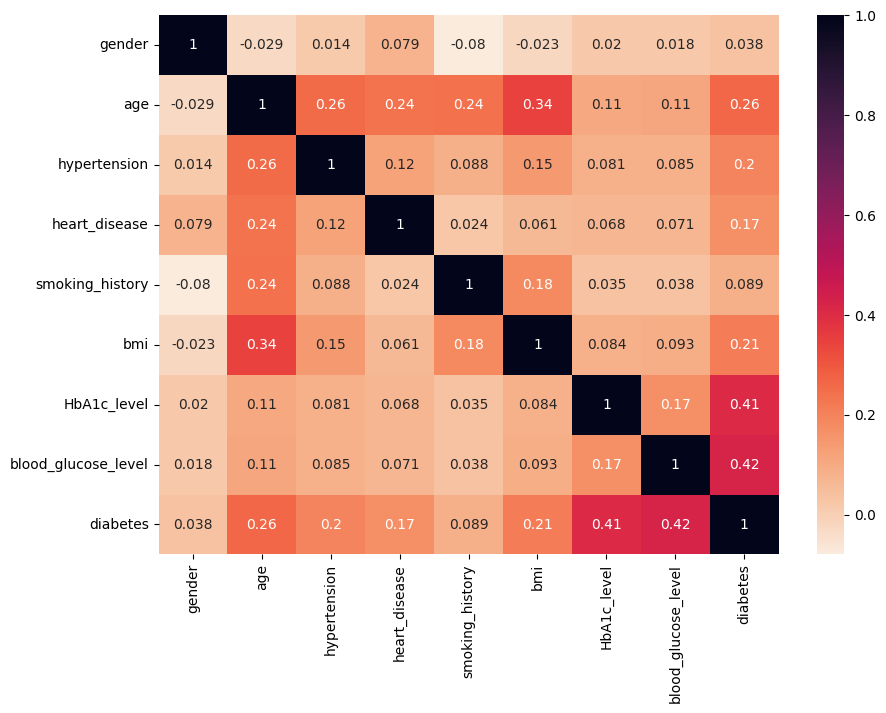

In [35]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(),annot=True,cmap="rocket_r")

**Histogram for age**

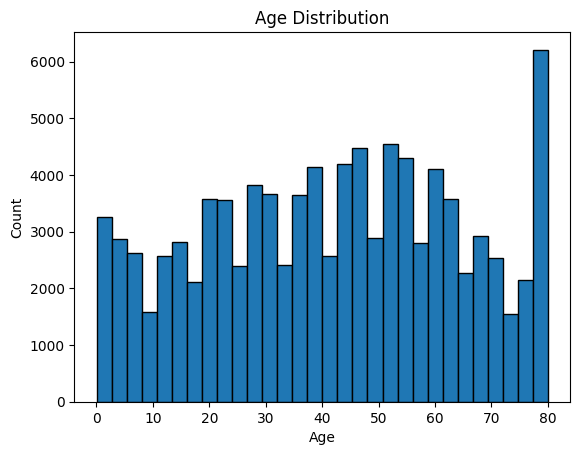

In [36]:
plt.hist(df['age'], bins=30, edgecolor='black')
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**Counts Plot**

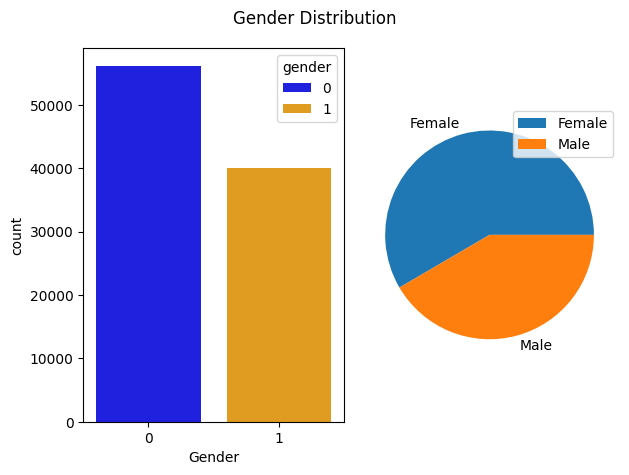

In [37]:
plt.subplot(1,2,1)
sns.countplot(x='gender',data=df,palette=['blue', 'orange'],hue='gender')
plt.xlabel('Gender')
plt.ylabel('count')
plt.suptitle('Gender Distribution')

plt.subplot(1,2,2)
plt.pie(df['gender'].value_counts(),labels=['Female','Male'])
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**Distribution plot for BMI**

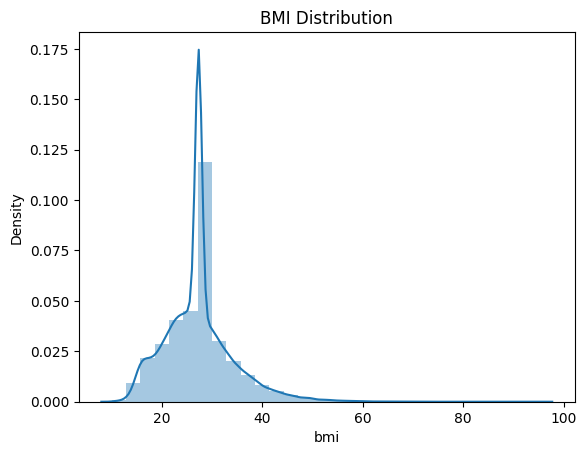

In [38]:
sns.distplot(df['bmi'],bins=30)
plt.title('BMI Distribution')
plt.show()

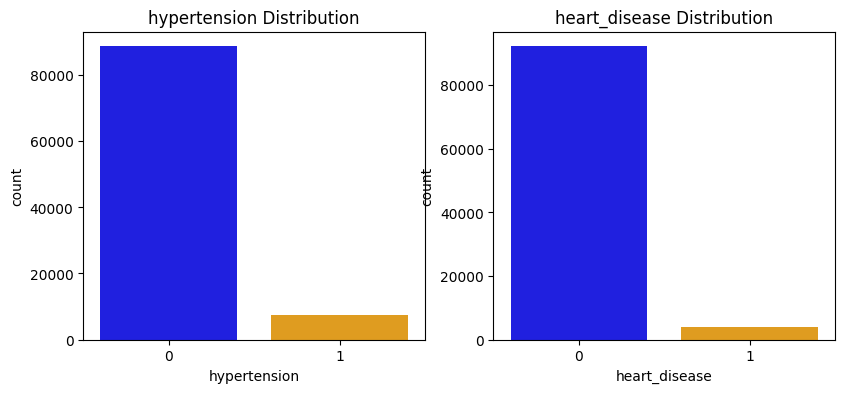

In [39]:
l=['hypertension', 'heart_disease']
plt.figure(figsize=(15,4))
for j in range(len(l)):
    plt.subplot(1, 3, j + 1)
    sns.countplot(x=l[j], data=df, palette=['blue', 'orange'])
    plt.title(f'{l[j]} Distribution')

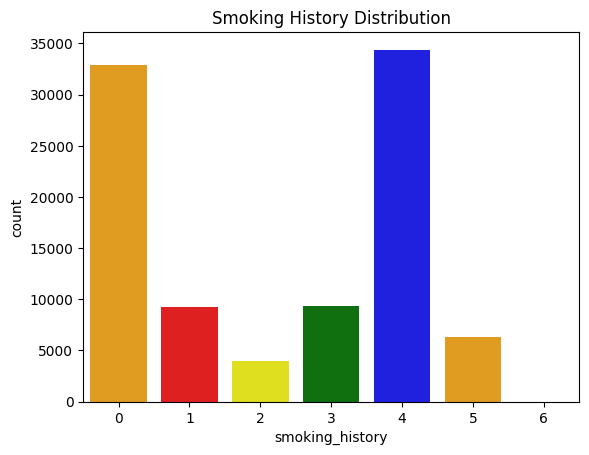

In [40]:
sns.countplot(x='smoking_history', data=df,palette=['orange','red','yellow','green','blue'])
plt.title('Smoking History Distribution')
plt.show()

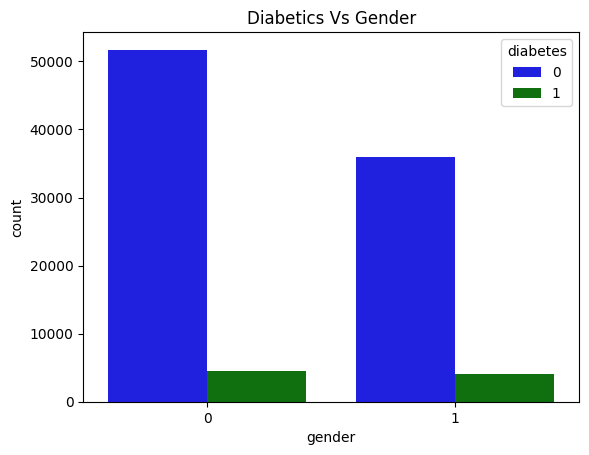

In [41]:
sns.countplot(x='gender',hue='diabetes',data=df,palette=['blue','green'])
plt.title('Diabetics Vs Gender')
plt.show()

**Scatterplot Age vs BMI colored by Diabetes classification**

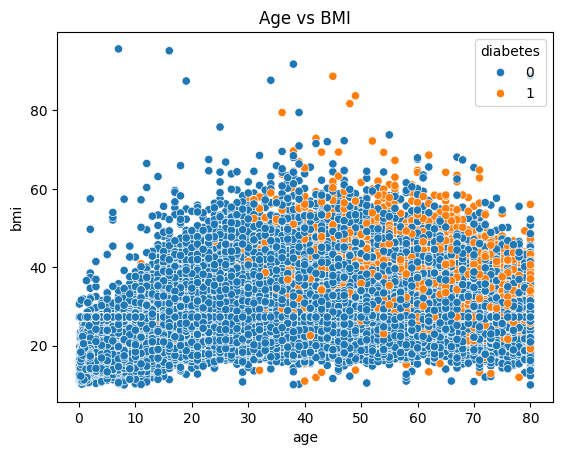

In [42]:
sns.scatterplot(x='age', y='bmi', hue='diabetes', data=df)
plt.title('Age vs BMI')
plt.show()

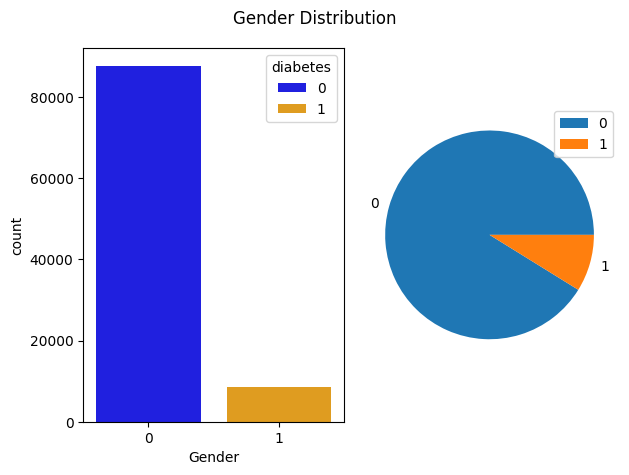

In [43]:
plt.subplot(1,2,1)
sns.countplot(x='diabetes',data=df,palette=['blue', 'orange'],hue='diabetes')
plt.xlabel('Gender')
plt.ylabel('count')
plt.suptitle('Gender Distribution')

plt.subplot(1,2,2)
plt.pie(df['diabetes'].value_counts(),labels=[0,1])
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

**The dataset is imbalanced dataset. it's essential to balance the data to ensure that the model doesn't get biased towards the majority class. For this purpose, the Synthetic Minority Over-sampling Technique (SMOTE) is used, which generates synthetic samples for the minority class.**

In [44]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.600000,140.0,0
1,0,54.0,0,0,0,27.32,6.600000,80.0,0
2,1,28.0,0,0,4,27.32,5.700000,158.0,0
3,0,36.0,0,0,1,23.45,5.000000,155.0,0
4,1,76.0,1,1,1,20.14,5.527516,155.0,0
...,...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,0,24.60,4.800000,145.0,0
99996,0,2.0,0,0,0,17.37,6.500000,100.0,0
99997,1,66.0,0,0,3,27.83,5.700000,155.0,0
99998,0,24.0,0,0,4,35.42,4.000000,100.0,0


**separate dependent and independent variables**

In [45]:
X=df.iloc[:,:-1]
X


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level
0,0,80.0,0,1,4,25.19,6.600000,140.0
1,0,54.0,0,0,0,27.32,6.600000,80.0
2,1,28.0,0,0,4,27.32,5.700000,158.0
3,0,36.0,0,0,1,23.45,5.000000,155.0
4,1,76.0,1,1,1,20.14,5.527516,155.0
...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,0,24.60,4.800000,145.0
99996,0,2.0,0,0,0,17.37,6.500000,100.0
99997,1,66.0,0,0,3,27.83,5.700000,155.0
99998,0,24.0,0,0,4,35.42,4.000000,100.0


In [46]:
X.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
dtype: int64

In [47]:
y=df.iloc[:,-1]
y

0        0
1        0
2        0
3        0
4        0
        ..
99994    0
99996    0
99997    0
99998    0
99999    0
Name: diabetes, Length: 96129, dtype: int64

In [48]:
y.value_counts()

diabetes
0    87647
1     8482
Name: count, dtype: int64

**Oversampling**

OVER

In [49]:
#pip install imbalanced-learn

In [50]:
#from imblearn.over_sampling import SMOTE


In [51]:
over=SMOTE(random_state=1)
X,y=over.fit_resample(X,y)


In [52]:
y.value_counts()

diabetes
0    87647
1    87647
Name: count, dtype: int64

In [53]:
df

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,80.0,0,1,4,25.19,6.600000,140.0,0
1,0,54.0,0,0,0,27.32,6.600000,80.0,0
2,1,28.0,0,0,4,27.32,5.700000,158.0,0
3,0,36.0,0,0,1,23.45,5.000000,155.0,0
4,1,76.0,1,1,1,20.14,5.527516,155.0,0
...,...,...,...,...,...,...,...,...,...
99994,0,36.0,0,0,0,24.60,4.800000,145.0,0
99996,0,2.0,0,0,0,17.37,6.500000,100.0,0
99997,1,66.0,0,0,3,27.83,5.700000,155.0,0
99998,0,24.0,0,0,4,35.42,4.000000,100.0,0


**Standardizing the features**

In [54]:
m=MinMaxScaler()
X=m.fit_transform(X)
X

array([[0.        , 1.        , 0.        , ..., 0.17717087, 0.56363636,
        0.27272727],
       [0.        , 0.67467467, 0.        , ..., 0.20203081, 0.56363636,
        0.        ],
       [1.        , 0.34934935, 0.        , ..., 0.20203081, 0.4       ,
        0.35454545],
       ...,
       [0.        , 0.6554985 , 0.        , ..., 0.48078925, 0.70306544,
        0.22727273],
       [0.        , 0.75907438, 0.        , ..., 0.54793434, 0.40463228,
        0.34669944],
       [0.        , 0.99369331, 1.        , ..., 0.26518591, 0.81671626,
        0.34090909]], shape=(175294, 8))

**Splitting the data into training and testing sets**

In [55]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=1)

In [56]:
X_train.shape,X_test.shape

((122705, 8), (52589, 8))

In [57]:
y_train.shape,y_test.shape

((122705,), (52589,))

**Model Building**

In [58]:
k=KNeighborsClassifier(n_neighbors=5)
r=RandomForestClassifier(n_estimators=100,random_state=1)
d=DecisionTreeClassifier(random_state=1)
a=AdaBoostClassifier(random_state=1)

model=[k,r,d,a]

for i in model:
  print( '              ',i        )
  print('**************************************************************')
  i.fit(X_train,y_train)
  y_pred=i.predict(X_test)
  print('accuracy=',accuracy_score(y_test,y_pred)*100)
  print(classification_report(y_test,y_pred))
  #print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred))
  print()
  print()


               KNeighborsClassifier()
**************************************************************
accuracy= 92.72851737055278
              precision    recall  f1-score   support

           0       0.95      0.91      0.93     26395
           1       0.91      0.95      0.93     26194

    accuracy                           0.93     52589
   macro avg       0.93      0.93      0.93     52589
weighted avg       0.93      0.93      0.93     52589



               RandomForestClassifier(random_state=1)
**************************************************************
accuracy= 97.25227709216756
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     26395
           1       0.97      0.97      0.97     26194

    accuracy                           0.97     52589
   macro avg       0.97      0.97      0.97     52589
weighted avg       0.97      0.97      0.97     52589



               DecisionTreeClassifier(random_state=1)
**************

### Cross Validation

In [59]:
from sklearn.model_selection import cross_val_score
import numpy as np

print("Cross Validation Scores for all models on training data:")
for i in model:
    print("              ", i.__class__.__name__)
    print("**************************************************************")
    # Using cv=3 and n_jobs=-1 for faster execution.
    scores = cross_val_score(i, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
    print(f"CV Accuracy Scores: {scores}")
    print(f"Mean Accuracy: {np.mean(scores)*100:.2f}%\n")


Cross Validation Scores for all models on training data:
               KNeighborsClassifier
**************************************************************
CV Accuracy Scores: [0.92056623 0.92359787 0.92381604]
Mean Accuracy: 92.27%

               RandomForestClassifier
**************************************************************
CV Accuracy Scores: [0.96748325 0.96672534 0.96819149]
Mean Accuracy: 96.75%

               DecisionTreeClassifier
**************************************************************
CV Accuracy Scores: [0.96623637 0.9666031  0.96603995]
Mean Accuracy: 96.63%

               AdaBoostClassifier
**************************************************************
CV Accuracy Scores: [0.91247372 0.91716786 0.91662796]
Mean Accuracy: 91.54%



**"The RandomForestClassifier achieved high accuracy of 97%, so we will use this model for deployment."**

### Hyperparameter Tuning

In [60]:
from sklearn.model_selection import RandomizedSearchCV

print("Starting Hyperparameter Tuning for RandomForest...")
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=1)
# Using n_iter=5 and cv=3 to keep tuning time reasonable. Increase for better results.
random_search = RandomizedSearchCV(
    estimator=rf, param_distributions=param_grid, 
    n_iter=5, cv=3, scoring='accuracy', n_jobs=-1, random_state=1
)
random_search.fit(X_train, y_train)

print(f"Best Parameters found: {random_search.best_params_}")
print(f"Best CV Score: {random_search.best_score_*100:.2f}%")

# Retrieve the best model to use in the subsequent evaluation and save steps
R = random_search.best_estimator_
y_pred_r = R.predict(X_test)
y_pred_r


Starting Hyperparameter Tuning for RandomForest...
Best Parameters found: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 30}
Best CV Score: 96.49%


array([0, 0, 1, ..., 0, 0, 1], shape=(52589,))

In [61]:
R=RandomForestClassifier(n_estimators=100,random_state=1)
R.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [62]:
y_pred_r=R.predict(X_test)
y_pred_r

array([0, 0, 1, ..., 0, 0, 1], shape=(52589,))

accuracy= 97.25227709216756
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     26395
           1       0.97      0.97      0.97     26194

    accuracy                           0.97     52589
   macro avg       0.97      0.97      0.97     52589
weighted avg       0.97      0.97      0.97     52589



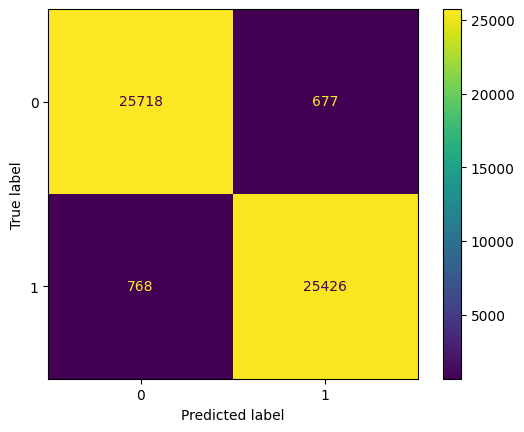

In [63]:
print('accuracy=',accuracy_score(y_test,y_pred_r)*100)
print(classification_report(y_test,y_pred_r))
print(ConfusionMatrixDisplay.from_predictions(y_test,y_pred_r))

In [64]:
y_new=R.predict(m.transform([[0,80.0,0,1,4,25.19,6.6,140]]))
if y_new==0:
  print('No Diabetes')
else:
  print('Diabetes')


No Diabetes


**Save Model**

In [65]:
pickle.dump(R,open('diabetes_model.save','wb'))
pickle.dump(m,open('diabetes_scaler.save','wb'))
pickle.dump(encoder,open('diabetics_encoder.save','wb'))
pickle.dump(encoder1,open('diabetics_encoder1.save','wb'))